In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
plt.rcParams['font.family'] = 'MS Gothic'
csv_file_path = 'emdat.csv'
emdat = pd.read_csv(csv_file_path)
emdat.head()

,sDisaster Subgroup,Disaster Type,Disaster Subtype,ISO,Country,Subregion,Region,Latitude,Longitude,Start Year,Total Deaths
0,Meteorological,Storm,Tropical cyclone,USA,United States of America,Northern America,Americas,NaN,NaN,1900,6000.0
1,Hydrological,Flood,Flood (General),JAM,Jamaica,Latin America and the Caribbean,Americas,NaN,NaN,1900,300.0
2,Biological,Epidemic,Viral disease,JAM,Jamaica,Latin America and the Caribbean,Americas,NaN,NaN,1900,30.0
3,Geophysical,Volcanic activity,Ash fall,JPN,Japan,Eastern Asia,Asia,NaN,NaN,1900,30.0
4,Geophysical,Earthquake,Ground movement,TUR,Türkiye,Western Asia,Asia,40.3,43.1,1900,140.0


## **チャレンジ 1: 国ごとの死亡者数を可視化**

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import io

def visualize_disaster_deaths_by_country(file_id: str, country_name: str):

    try:
        df = pd.read_csv(file_id)

        df.columns = df.columns.str.strip()

        df['Country'] = df['Country'].astype(str).str.strip()
        country_data = df[df['Country'].str.lower() == country_name.lower()]

        if country_data.empty:
            print(f"指定された国 '{country_name}' のデータは見つかりませんでした。データセット内の国名を確認してください。")
            return

        country_data = country_data.copy()
        country_data.loc[:, 'Total Deaths'] = country_data['Total Deaths'].fillna(0).astype(int)
        
        death_counts = country_data.groupby('Disaster Type')['Total Deaths'].sum().sort_values(ascending=False)

        if death_counts.sum() == 0:
            print(f"指定された国 '{country_name}' のデータには、記録された総死亡者数がありませんでした。")
            return

        plt.figure(figsize=(12, 6))
        death_counts.plot(kind='bar', color='skyblue')
        
        plt.title(f'{country_name} における災害タイプ別 総死亡者数', fontsize=16)
        plt.xlabel('災害タイプ', fontsize=12)
        plt.ylabel('総死亡者数', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--')
        plt.tight_layout()
        plt.show()

    except FileNotFoundError:
        print(f"エラー: ファイルID '{file_id}' のデータファイルが見つかりません。")
    except Exception as e:
        print(f"データの処理中にエラーが発生しました: {e}")

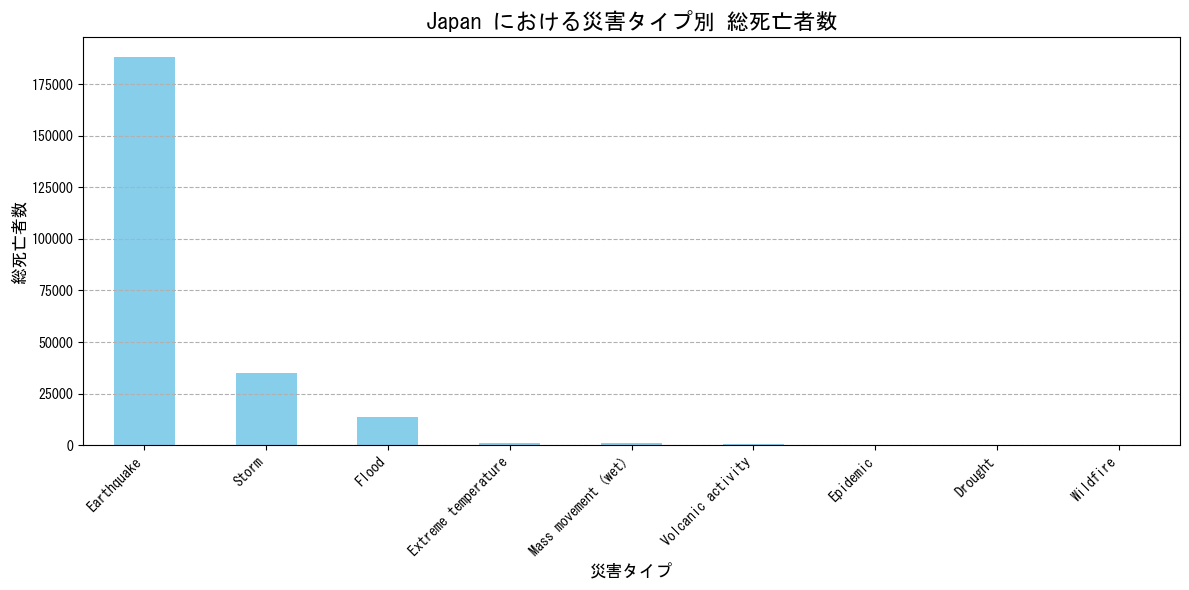

In [15]:
visualize_disaster_deaths_by_country(file_id="emdat.csv", country_name="Japan")

## **チャレンジ 2: 2つの国の死亡者数を比較**

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import io

def compare_disaster_deaths_between_countries(file_id: str, country_name_1: str, country_name_2: str):
    
    try:
        df = pd.read_csv(file_id)

        df.columns = df.columns.str.strip()
        df['Country'] = df['Country'].astype(str).str.strip()

        countries_to_compare = [country_name_1.lower(), country_name_2.lower()]

        comparison_data = df[df['Country'].str.lower().isin(countries_to_compare)].copy()

        if comparison_data.empty:
            print(f"指定された国 '{country_name_1}' または '{country_name_2}' のデータが見つかりませんでした。データセット内の国名を確認してください。")
            return

        comparison_data.loc[:, 'Total Deaths'] = comparison_data['Total Deaths'].fillna(0).astype(int)

        comparison_pivot = comparison_data.groupby(['Country', 'Disaster Type'])['Total Deaths'].sum().unstack(level=0)

        comparison_pivot = comparison_pivot[[country_name_1, country_name_2]].fillna(0)

        comparison_pivot['Total'] = comparison_pivot.sum(axis=1)
        comparison_pivot = comparison_pivot.sort_values(by='Total', ascending=False).drop(columns=['Total'])

        if comparison_pivot.empty or comparison_pivot.sum().sum() == 0:
            print(f"指定された2カ国 '{country_name_1}' と '{country_name_2}' の比較可能な死亡者データがありませんでした。")
            return

        plt.figure(figsize=(14, 7))
        comparison_pivot.plot(kind='bar', figsize=(14, 7), width=0.8)

        plt.title(f'{country_name_1} と {country_name_2} における災害タイプ別 総死亡者数の比較', fontsize=16)
        
        plt.xlabel('災害タイプ', fontsize=12)
        plt.ylabel('総死亡者数', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='国名')
        plt.grid(axis='y', linestyle='--')
        plt.tight_layout()
        plt.show()

    except FileNotFoundError:
        print(f"エラー: ファイルID '{file_id}' のデータファイルが見つかりません。")
    except Exception as e:
        print(f"データの処理中にエラーが発生しました: {e}")

<Figure size 1400x700 with 0 Axes>

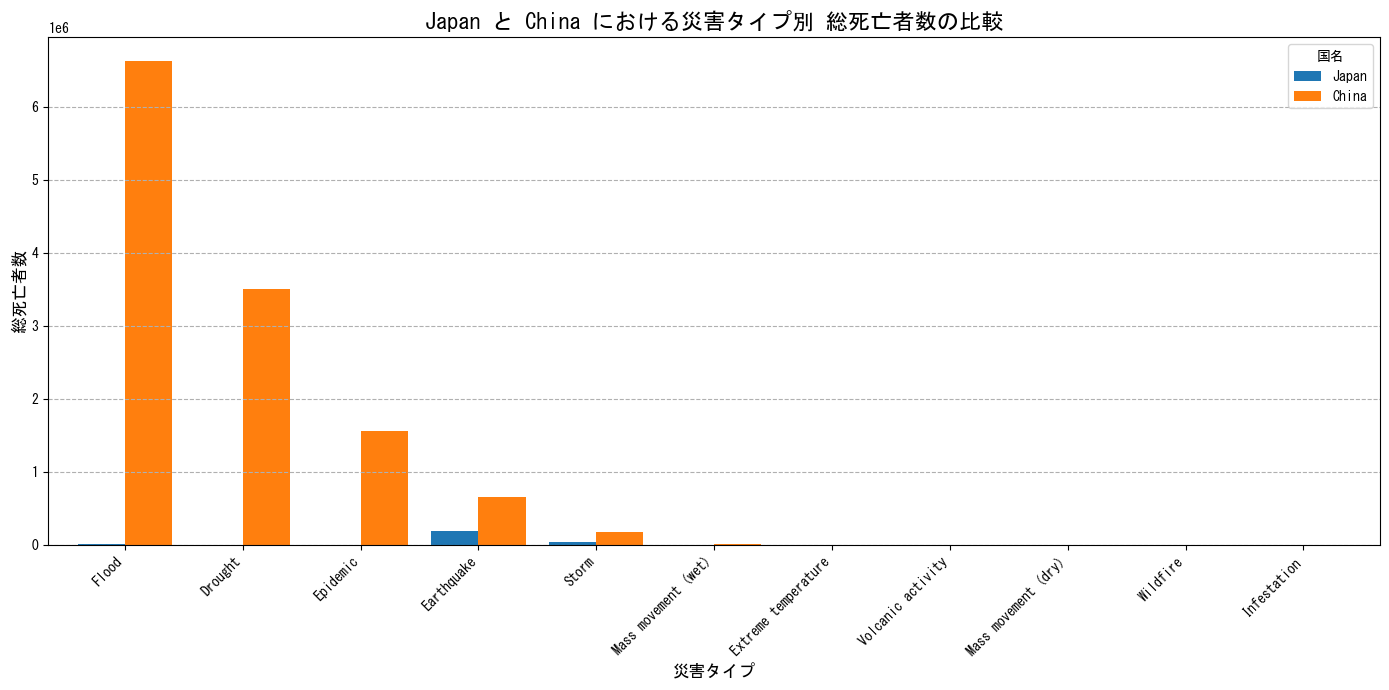

In [23]:
compare_disaster_deaths_between_countries(file_id="emdat.csv", country_name_1="Japan", country_name_2="China")

## **チャレンジ 3: 最も致命的な災害トップNを可視化**

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import io

def visualize_top_n_deadliest_disasters(file_id: str, top_n: int = 5):

    try:
        df = pd.read_csv(file_id)

        df.columns = df.columns.str.strip()

        df_processed = df.copy()
        df_processed.loc[:, 'Total Deaths'] = df_processed['Total Deaths'].fillna(0).astype(int)

        death_counts_by_type = df_processed.groupby('Disaster Type')['Total Deaths'].sum()

        top_n_disasters = death_counts_by_type.nlargest(top_n)

        if top_n_disasters.empty or top_n_disasters.sum() == 0:
            print("集計可能な死亡者データ、または十分なデータが見つかりませんでした。")
            return

        plt.figure(figsize=(10, 6))

        colors = plt.cm.get_cmap('Reds', top_n)
        
        top_n_disasters.plot(kind='bar', color=colors(range(top_n)))
        
        plt.title(f'全期間・全地域における最も致命的な災害 トップ{top_n}件', fontsize=16)
        plt.xlabel('災害タイプ', fontsize=12)
        plt.ylabel('総死亡者数 (累積)', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.ticklabel_format(style='plain', axis='y') # y軸の表記を科学記法から通常の数値へ
        plt.grid(axis='y', linestyle='--')
        plt.tight_layout()
        plt.show()

    except FileNotFoundError:
        print(f"エラー: ファイルID '{file_id}' のデータファイルが見つかりません。")
    except Exception as e:
        print(f"データの処理中にエラーが発生しました: {e}")

C:\Users\donbu\AppData\Local\Temp\ipykernel_10576\1785315963.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Reds', top_n)


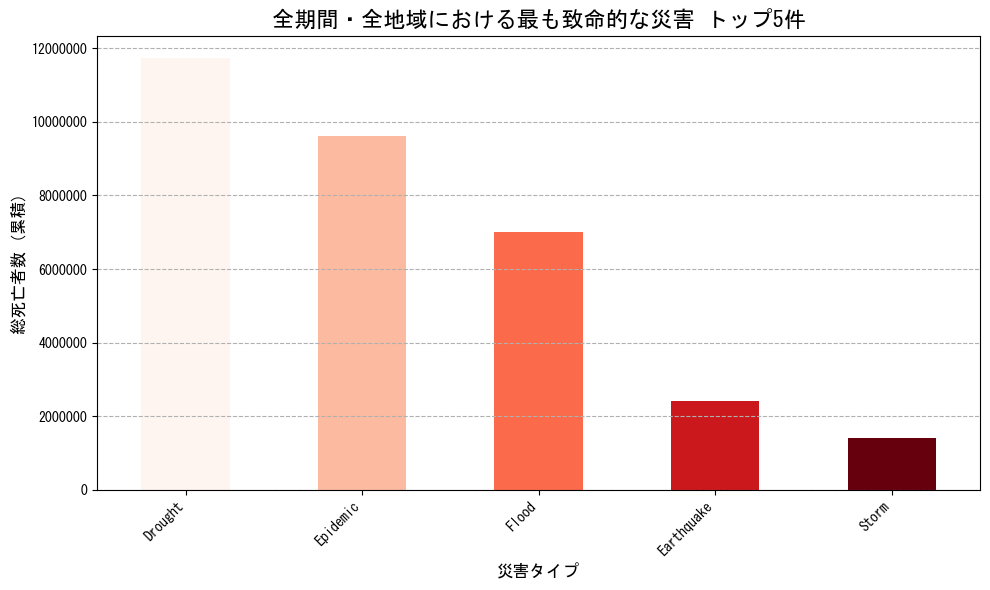

In [38]:
visualize_top_n_deadliest_disasters(file_id="emdat.csv", top_n=5)

## **チャレンジ 4: 特定の年範囲での死亡者数を可視化**

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import io

def visualize_deaths_over_time(file_id: str, start_year: int, end_year: int):

    try:
        df = pd.read_csv(file_id)

        df.columns = df.columns.str.strip()

        df_processed = df.copy()
        df_processed.loc[:, 'Start Year'] = df_processed['Start Year'].astype(int)

        df_processed.loc[:, 'Total Deaths'] = df_processed['Total Deaths'].fillna(0).astype(int)

        filtered_data = df_processed[
            (df_processed['Start Year'] >= start_year) & 
            (df_processed['Start Year'] <= end_year)
        ]

        if filtered_data.empty:
            print(f"指定された年範囲 ({start_year}年〜{end_year}年) のデータが見つかりませんでした。")
            return

        yearly_deaths = filtered_data.groupby('Start Year')['Total Deaths'].sum()

        if yearly_deaths.empty or yearly_deaths.sum() == 0:
            print(f"指定された年範囲 ({start_year}年〜{end_year}年) には、記録された総死亡者数がありませんでした。")
            return

        plt.figure(figsize=(12, 6))
        yearly_deaths.plot(kind='line', marker='o', color='red', linestyle='-')
        
        plt.title(f'{start_year}年〜{end_year}年における世界全体の災害による総死亡者数の推移', fontsize=16)
        plt.xlabel('年', fontsize=12)
        plt.ylabel('総死亡者数', fontsize=12)
        plt.xticks(yearly_deaths.index, rotation=45)
        plt.ticklabel_format(style='plain', axis='y') 
        plt.grid(axis='both', linestyle='--')
        plt.tight_layout()
        plt.show()

    except FileNotFoundError:
        print(f"エラー: ファイルID '{file_id}' のデータファイルが見つかりません。")
    except Exception as e:
        print(f"データの処理中にエラーが発生しました: {e}")

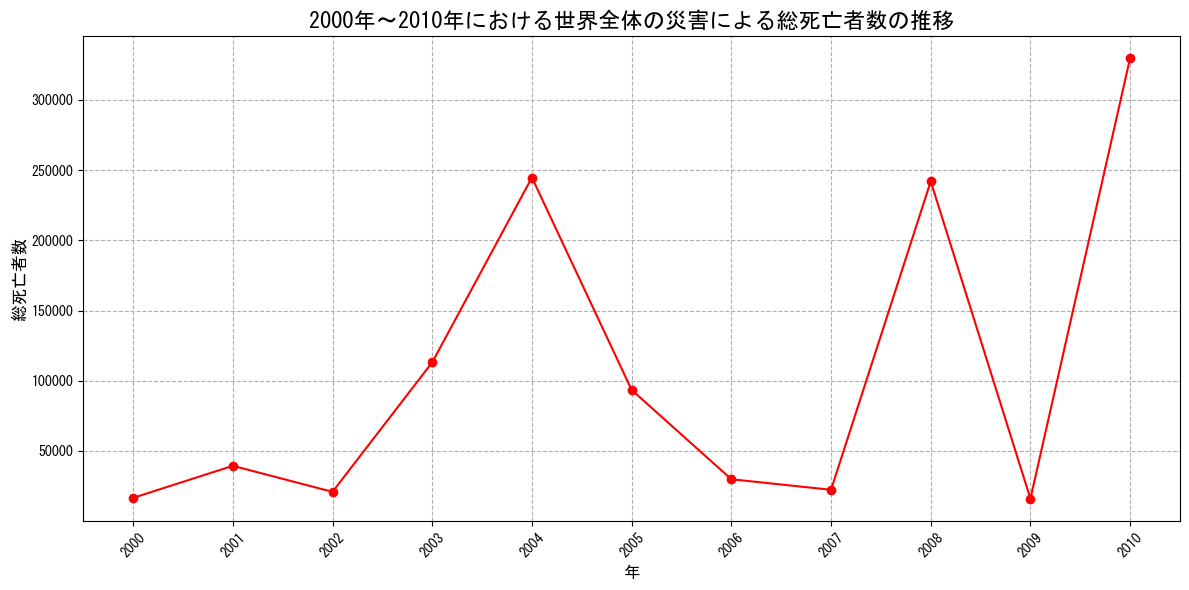

In [40]:
visualize_deaths_over_time(file_id="emdat.csv", start_year=2000, end_year=2010)

## **チャレンジ 5: カスタム可視化を作成**

### **災害の変遷分析レポート：過去と現在の比較**

#### **1．はじめに**
今回の分析の目的は、世界全体で発生した災害データに基づいて、「過去の時代」と「現代」で最も人命に大きな被害をもたらした災害タイプがどのように変遷したかを明らかにすること。

データを1960年を境に2つの期間に分け、それぞれの期間で「総死亡者数」が多かった上位5件の災害タイプを抽出し、比較する。

・過去の期間: 1900年から1960年

・現在の期間: 1961年から最新年

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import io

def analyze_disaster_lethality_change(file_id: str, split_year: int = 1960, top_n: int = 5):

    try:
        df = pd.read_csv(file_id)
        df.columns = df.columns.str.strip()
        df_processed = df.copy()
        df_processed.loc[:, 'Start Year'] = df_processed['Start Year'].astype(int)
        df_processed.loc[:, 'Total Deaths'] = df_processed['Total Deaths'].fillna(0).astype(int)
        latest_year = df_processed['Start Year'].max()

        periods = {
            f"過去 ({df_processed['Start Year'].min()}年〜{split_year}年)": 
                (df_processed['Start Year'].min(), split_year),
            f"現在 ({split_year + 1}年〜{latest_year}年)": 
                (split_year + 1, latest_year)
        }
        
        all_results = {}
        for period_name, (start, end) in periods.items():
            period_data = df_processed[
                (df_processed['Start Year'] >= start) & 
                (df_processed['Start Year'] <= end)
            ]
            death_counts = period_data.groupby('Disaster Type')['Total Deaths'].sum()
            top_n_disasters = death_counts.nlargest(top_n)
            all_results[period_name] = top_n_disasters

        fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=False) 
        fig.suptitle(f'過去と現在における総死亡者数に基づく危険な災害タイプの上位{top_n}件の変遷', fontsize=18)
        
        colors = ['darkred', 'steelblue'] 
        
        for i, (period_name, ranking) in enumerate(all_results.items()):

            ranking_sorted = ranking.sort_values(ascending=True)
            ranking_sorted.plot(
                kind='barh', 
                ax=axes[i], 
                color=colors[i]
            )

            axes[i].set_title(period_name, fontsize=14)
            axes[i].set_xlabel('総死亡者数', fontsize=12)
            axes[i].ticklabel_format(style='plain', axis='x')

            if i == 0:
                axes[i].set_ylabel('災害タイプ', fontsize=12)
            else:
                axes[i].set_ylabel('')
            
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

    except FileNotFoundError:
        print(f"エラー: ファイルID '{file_id}' のデータファイルが見つかりません。")
    except Exception as e:
        print(f"データの処理中にエラーが発生しました: {e}")

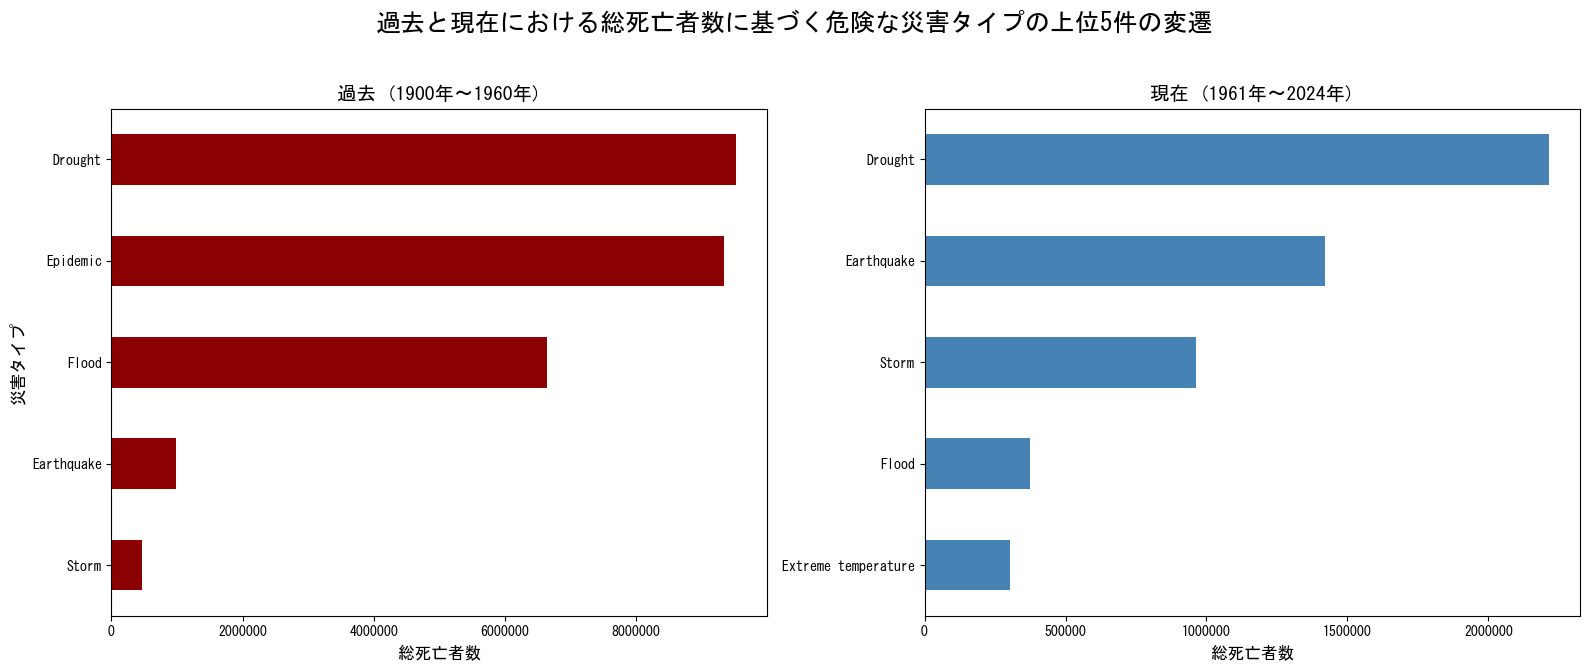

In [61]:
analyze_disaster_lethality_change(file_id="emdat.csv", split_year=1960, top_n=5)

#### **2．分析結果**
分析結果から、過去の期間と現在の期間では、人命に最も影響を与えた災害の性質に決定的な違いがあることが確認された。

#### **2.1．過去の期間（1900年〜1960年）の傾向**
この期間は、「人災的要因」が非常に大きな影響を与えていたことが特徴。

干ばつと伝染病の突出: 1位の干ばつと2位の伝染病だけで、この期間の総死亡者の大部分を占めている。これは、干ばつが引き起こす大規模な飢饉や、衛生環境の悪さから連鎖的に発生した疾病が、当時の最も致命的な要因であったことを示している。

地震の相対的な低さ: 地震の死亡者数は約99万人と、干ばつや伝染病と比較して相対的に低い位置にある。

#### **2.2．現在の期間（1961年〜2024年）の傾向**
現在の期間では、死亡者数の規模自体が過去よりも大幅に縮小した中で、「突発的・自然破壊的要因」が上位を占めている。

干ばつの死亡者数の激減: 干ばつは引き続き1位であるが、総死亡者数は過去の約4分の1以下に減少した。

伝染病のランキングからの消失: 過去に2位だった伝染病は上位5位から外れた。

地震の順位上昇と死亡者数増加: 地震は2位に順位を上げ、総死亡者数も過去の期間と比較して増加している。

異常気温の新規参入: 過去には見られなかった異常気温が5位に入っており、新たな脅威の出現を示している。

### **3．考察**
考察１：飢餓と病気は克服された

過去のランキングで上位だった干ばつと伝染病の死亡者数が、大幅に減少していた。このことから、この100年間で医療技術や衛生環境が向上したと考えられる。これによって、災害が起こった時でもそれが飢餓などに直結するリスクを抑えられるようになります。

考察２：地震は現在も過去も脅威である

過去のランキングで4位だった地震が、現在のランキングでは2位に上昇し、死亡者数も増えている。これは、都市への人口集中が進み、一度の地震で多くの人が住む建物が崩壊するリスクが高まっているからだ。地震は予測が難しいため、人命への被害を防ぐのが難しい。地震への対策は大きな課題となると思った。

考察３：地球温暖化による新たな脅威
現在のランキングに異常気温が新たに登場している。これは、地球温暖化によって異常な暑さや寒さが頻繁に起こるようになり、とくに高齢者を脅かし始めていることを示している。自然災害だけでなく、気候変動のリスクにも備える必要がある。